# Ejemplo de uso: línea ESTÁTICA (`src.static`)

Notebook autocontenido para comprobar que la refactorización funciona y
ver el flujo completo del motor estático:
**parámetros → red → motor → `run()` → figuras, observables y comprobaciones.**

| Pieza | Clase refactorizada | Origen | Alias heredado |
|---|---|---|---|
| Parámetros | `KMCParamsStatic` | `params_v4.py` | `KMCParams_v4` |
| Red SOS | `LatticeSOSStatic` | `lattice_v3.py` | `LatticeSOS_v3`, `LatticeSOS_v4` |
| Motor BKL | `KMC_BKL_Static` | `bkl_v4.py` (+ opciones de `bkl_v5.py`) | `KMC_BKL_v4` |

**Qué caracteriza a esta línea**
- La sobresaturación **no cambia** durante la corrida: se fija con `fixed_sigma`
  (σ = C/C_eq − 1; el motor usa S = ln(1 + σ)) o con concentración constante.
- Admite **anisotropía**: energías de enlace y δ distintas en x e y
  (`E_pb_over_kT_x/_y`, `delta_x/_y`), además de factores de solvente.
- `run()` devuelve `(snaps, stats)`: snapshots de alturas e historiales por evento.

**Colores de las morfologías** (estilo `"paper"` del `Plotter`, como la Fig. 9 de
Nagpal et al. 2024, `references/modern_kMC/`):
- **azul**: capa completamente llena (todos los niveles por debajo de `min(heights)`);
- **rojo**: capa en crecimiento (todo lo que está por encima).

Tiempo de ejecución estimado: 1–3 min (red 30×30, unos 6000 eventos). Todo se muestra
en las celdas; lo único que se escribe a disco es el GIF, en una carpeta temporal.

## 1. Imports

In [2]:
%matplotlib inline
import copy
import sys
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display   # solo para mostrar el GIF en la celda

# Busca la carpeta que CONTIENE src/ (la raíz del repo) subiendo desde el directorio actual:
# funciona con el notebook abierto desde notebooks/ o desde la raíz del repo.
_candidatos = [Path.cwd(), *Path.cwd().parents]
REFAC = next(p for p in _candidatos if (p / "src" / "static" / "engine.py").exists())
if str(REFAC) not in sys.path:
    sys.path.insert(0, str(REFAC))

from src.static import KMC_BKL_Static, KMCParamsStatic, LatticeSOSStatic
from src.plotting import Plotter
from src.common.observables import count_by_coordination, mean_height, roughness, step_density

print("Código importado desde:", REFAC / "src")
print("numpy", np.__version__)

Código importado desde: /home/sggphysics/kMC_Malaria/src
numpy 2.5.3


## 2. Parámetros

Valores de `scripts/configs/single_iso.json` (antes `src/pRun.py`).

| Parámetro | Significado |
|---|---|
| `K0_plus` | prefactor de adsorción, desorción y migración |
| `K_inc_plus` | prefactor de incorporación |
| `E_pb_over_kT_x`, `E_pb_over_kT_y` | energía de enlace lateral / kT en x e y |
| `phi_over_kT` | energía de superficie / kT |
| `delta_x`, `delta_y` | parámetro adaptativo de la adsorción (δ del artículo, Ec. 7) |
| `V`, `C_eq` | volumen y concentración de equilibrio (solo cuentan sin `fixed_sigma`) |
| `fixed_sigma` | σ fija; el motor usa S = ln(1 + σ) |
| `S_floor`, `S_ceil` | límites de S |

Para la variante anisotrópica basta cambiar x ≠ y, por ejemplo con los valores de
`scripts/configs/single_aniso.json`: `E_pb_over_kT_x=1.2705`, `E_pb_over_kT_y=2.2705`,
`delta_x=0.3`, `delta_y=1.0`.

In [3]:
params = KMCParamsStatic(
    K0_plus=0.2116718,
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT_x=2.2704636027368603,   # x = y -> isotrópico
    E_pb_over_kT_y=2.2704636027368603,
    phi_over_kT=1.379247801207933,
    delta_x=1.3,
    delta_y=1.3,
    V=1,
    C_eq=15.0,
    fixed_sigma=1.0,                     # σ constante durante toda la corrida
    S_floor=-5.0,
    S_ceil=9.0,
)
params

KMCParamsStatic(K0_plus=0.2116718, E_pb_over_kT_x=2.2704636027368603, E_pb_over_kT_y=2.2704636027368603, phi_over_kT=1.379247801207933, delta_x=1.3, delta_y=1.3, V=1, C_eq=15.0, K_inc_plus=0.5069325183371898, fixed_sigma=1.0, S_floor=-5.0, S_ceil=9.0, solvent_ads_factor=1.0, solvent_des_factor=1.0, solvent_mig_factor=1.0, solvent_inc_factor=1.0)

## 3. Red y motor

`LatticeSOSStatic.initialize(mode=...)` admite `"flat"`, `"random"`, `"seeds"` (isla
compacta en el centro) y `"screw"` (dislocación helicoidal). Aquí se usa `"seeds"`: una
sola isla que crece, como en el régimen espiral de la Fig. 9a.

La construcción se envuelve en una función para poder crear motores idénticos más
abajo (prueba de determinismo).

In [4]:
L = 30          # red L x L con condiciones de contorno periódicas
N_ISLA = 64     # sitios de la isla inicial (modo "seeds")


def crear_motor() -> KMC_BKL_Static:
    """Red + motor con semillas fijas: misma trayectoria cada vez que se llama."""
    lat = LatticeSOSStatic(size=(L, L), seed=42)
    lat.initialize(mode="seeds", n_seeds=N_ISLA)
    return KMC_BKL_Static(
        lattice=lat,
        params=params,
        N_bulk0=2000,                   # con σ fija solo afecta a conversion_percent
        rng_seed=123,
        time_scale=100,
        constant_concentration=True,
        record_adsorption_probs=True,   # necesario para plot_adsorption_probabilities;
                                        # False es ~1.8x más rápido (misma trayectoria)
    )


kmc = crear_motor()
print(f"σ = {kmc.sigma:.3f} | S = ln(1+σ) = {kmc.supersaturation:.3f}")
print(f"Masa inicial en la red (N_seed0): {kmc.N_seed0} partículas")

σ = 1.000 | S = ln(1+σ) = 0.693
Masa inicial en la red (N_seed0): 64 partículas


## 4. ¿Hasta qué tiempo simular?

El tiempo kMC avanza Δt = −ln(ξ)/W_tot · `time_scale` por evento, así que cuántos
eventos caben en una unidad de tiempo depende de las tasas. Una corrida piloto corta
sobre una **copia** del motor (no altera `kmc` ni su generador aleatorio) da el tiempo
medio por evento. Con σ constante ese valor es aproximadamente estacionario.

In [5]:
N_EVENTOS = 6000    # súbelo para ver más capas (el coste crece de forma lineal)

piloto = copy.deepcopy(kmc)
piloto.run(t_end=np.inf, max_events=300)
dt_evento = piloto.t / 300
T_END = dt_evento * N_EVENTOS
print(f"≈ {dt_evento:.3e} u.t. por evento  ->  T_END ≈ {T_END:.4g} u.t. para ~{N_EVENTOS} eventos")

≈ 5.122e-04 u.t. por evento  ->  T_END ≈ 3.073 u.t. para ~6000 eventos


## 5. Simulación

`run(t_end, snapshot_times, max_events)` para en `t_end` o en `max_events`. Cada
snapshot es una tupla `(t, heights, conversion_percent)`. Si se llega a `max_events`
antes de `t_end`, los snapshots que faltan se rellenan con el estado final.

In [6]:
snapshot_times = np.linspace(0, T_END, 9)    # 9 instantáneas equiespaciadas

t0 = time.perf_counter()
snaps, stats = kmc.run(t_end=T_END, snapshot_times=snapshot_times, max_events=3 * N_EVENTOS)
duracion = time.perf_counter() - t0

print(f"Cómputo: {duracion:.1f} s ({1e3 * duracion / stats['total_events']:.2f} ms/evento)")
print(f"Tiempo simulado: {stats['total_time']:.4g} u.t. (objetivo {T_END:.4g})")
print(f"Eventos totales: {stats['total_events']}")
for evento, n in stats["event_counts"].items():
    print(f"   {evento:<14s}{n:>8d}")
print(f"conversion_percent       = {kmc.conversion_percent:6.2f} %  (eventos de incorporación, definición v4)")
print(f"crystal_fraction_percent = {kmc.crystal_fraction_percent:6.2f} %  (masa en la red / (N0 + N_seed0), definición v5)")
if kmc.t < T_END:
    print("⚠️ Se alcanzó max_events antes de T_END: los últimos snapshots repiten el estado final.")
print("stats contiene:", list(stats))

Cómputo: 28.0 s (4.46 ms/evento)
Tiempo simulado: 3.074 u.t. (objetivo 3.073)
Eventos totales: 6291
   adsorption          23
   desorption           0
   migration            3
   incorporation     6265
conversion_percent       =  75.80 %  (eventos de incorporación, definición v4)
crystal_fraction_percent =   4.22 %  (masa en la red / (N0 + N_seed0), definición v5)
stats contiene: ['height_history', 'adsorption_probs_history', 'event_counts', 'incorporated_count', 'conversion_percent', 'conversion_history', 'total_time', 'total_events']


## 6. Morfología (estilo del artículo)

`Plotter(kmc, style="paper")`: azul = capa completa, rojo = capa en crecimiento. Por
defecto se dibuja el último snapshot; `t_snapshot=...` elige el más cercano a un
tiempo dado.

🧩 Usando último snapshot disponible: t=3.073 (conv=75.80%)


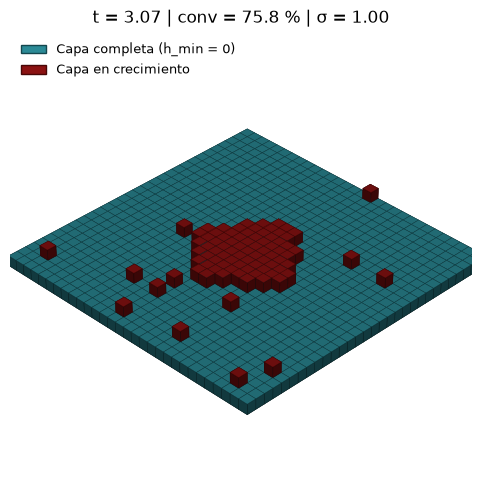

In [7]:
plotter = Plotter(kmc, style="paper")
plotter.plot_crystal_3d(snapshots=snaps)

Secuencia de instantes en fila, como la Fig. 9. Con `times=[...]` se eligen tiempos
concretos; si no, se toman `n_panels` snapshots equiespaciados.

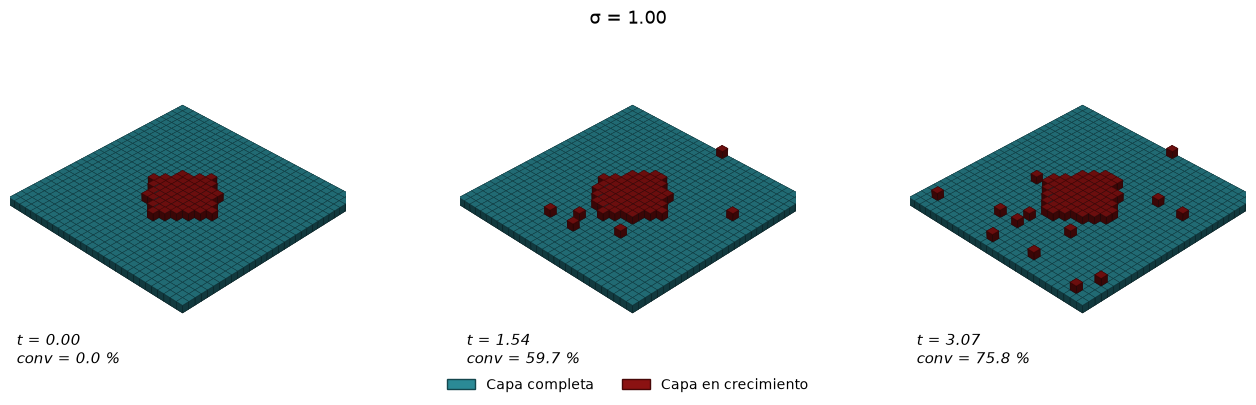

In [8]:
plotter.plot_morphology_sequence(snaps, n_panels=3)

Los estilos antiguos siguen disponibles y reproducen píxel a píxel los plotters
originales (`classic` = `plotter.py`, `v2` = `plotter_v2.py`, `academic` =
`plotter_v3.py`). Por ejemplo, la superficie iluminada de `v2`:

🧩 Usando último snapshot disponible: t=3.073 (conv=75.80%)


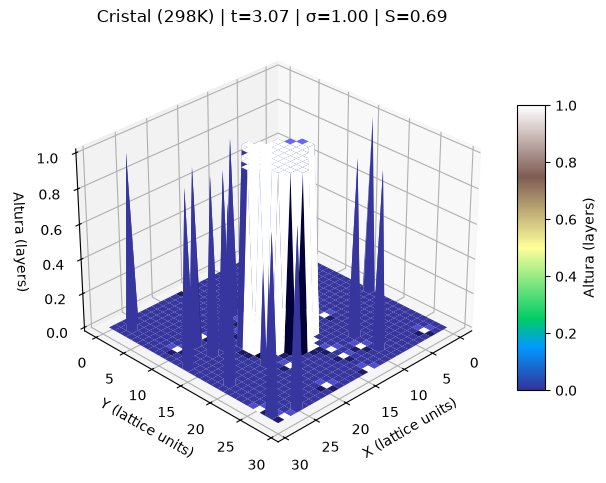

In [9]:
Plotter(kmc, style="v2").plot_crystal_3d(mode="surface", snapshots=snaps)

## 7. Observables y análisis

In [10]:
h = kmc.lat.heights
print(f"Altura media           : {mean_height(h):.3f} capas")
print(f"Rugosidad (std de h)   : {roughness(h):.3f}")
print(f"Densidad de escalones  : {step_density(kmc.lat):.3f}")
print(f"Sitios por coordinación: {count_by_coordination(kmc.lat)}")

Altura media           : 0.097 capas
Rugosidad (std de h)   : 0.296
Densidad de escalones  : 0.000
Sitios por coordinación: {0: 821, 1: 62, 2: 17, 3: 0, 4: 0}


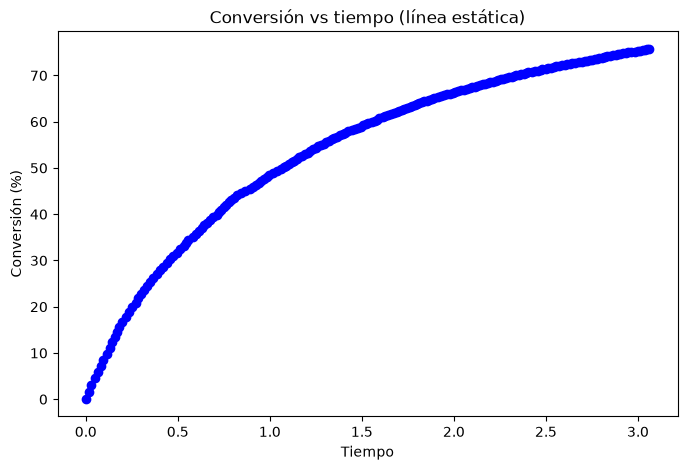

In [11]:
# conversion_history tiene un punto por evento: se submuestrea para que se lea mejor
conv_hist = stats["conversion_history"][::max(1, stats["total_events"] // 200)]
plotter.plot_conversion([(t, None, c) for t, c in conv_hist],
                        title="Conversión vs tiempo (línea estática)")

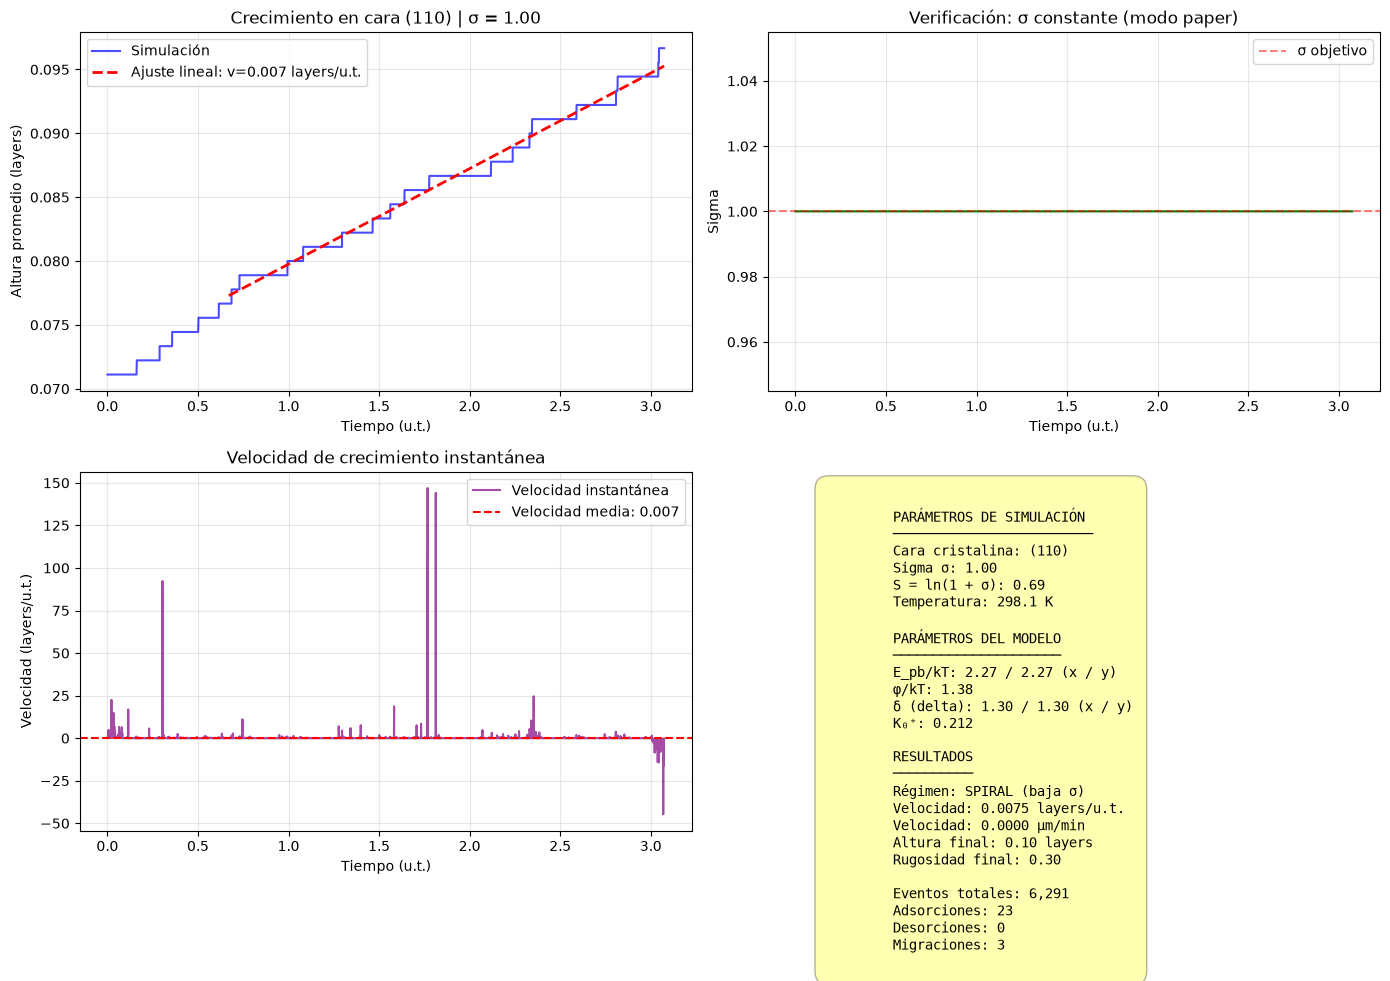

{'growth_rate_layers': np.float64(0.007479632964312192),
 'growth_rate_um_min': np.float64(2.6178715375092672e-05),
 'regimen': 'SPIRAL (baja σ)',
 'final_height': np.float64(0.09666666666666666),
 'final_roughness': np.float64(0.29550333707459586)}

In [12]:
# Altura media vs tiempo, verificación de σ constante y velocidad de crecimiento
resultado = plotter.plot_growth_rate_analysis(stats, sigma=kmc.sigma, face="110")
resultado

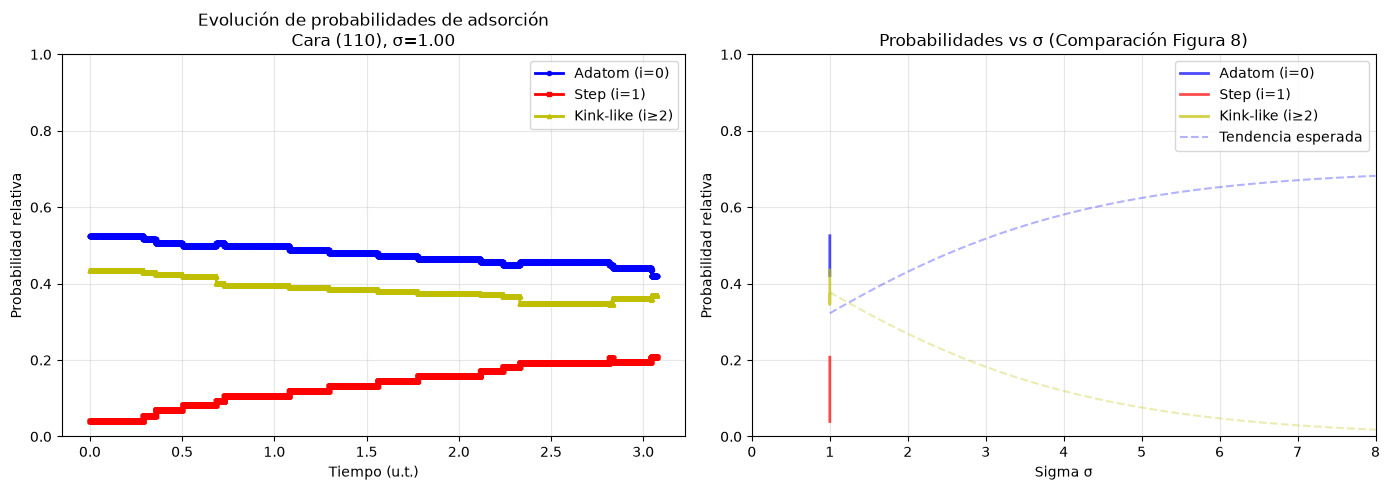

In [13]:
# Probabilidades de adsorción por tipo de sitio (requiere record_adsorption_probs=True)
plotter.plot_adsorption_probabilities(stats, sigma=kmc.sigma, face="110")

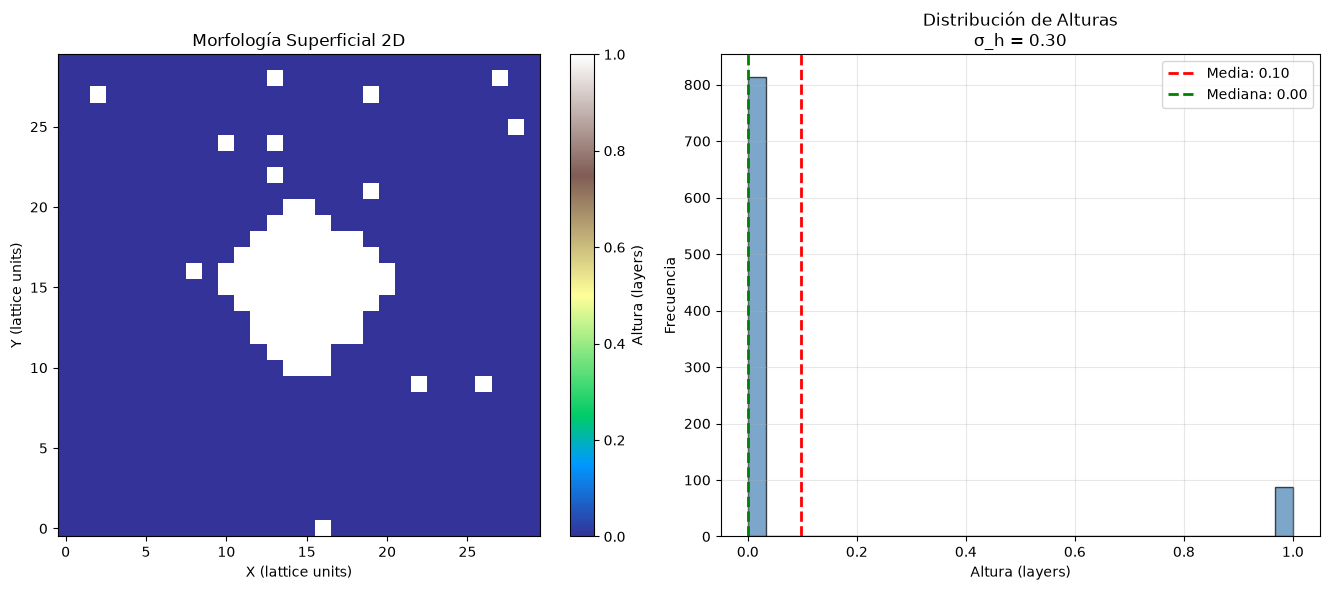

In [14]:
plotter.plot_surface_morphology()

## 8. GIF del crecimiento

Se guarda en una carpeta temporal y se muestra aquí mismo.

💾 GIF guardado en: /tmp/tmpthr7i1li/linea_estatica.gif


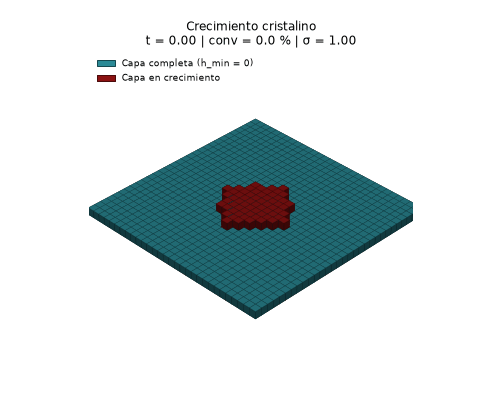

In [15]:
gif_path = Path(tempfile.mkdtemp()) / "linea_estatica.gif"
plotter.crystal_growth_gif(snaps, save_path=str(gif_path), fps=3, dpi=70)
display(Image(filename=str(gif_path)))

## 9. Comprobaciones

La validación fuerte de la refactorización está en `tests/`: `test_golden.py` compara
bit a bit con el código original y `test_plotter.py` compara las figuras píxel a píxel.
Aquí solo se comprueban invariantes del uso normal:

1. cada evento queda registrado una sola vez;
2. conservación de masa en la red: solo la adsorción (+1) y la desorción (−1) cambian
   la suma de alturas; la migración mueve partículas y la incorporación solo actualiza
   la contabilidad química;
3. σ se mantiene constante en toda la corrida;
4. determinismo: con las mismas semillas se obtiene la misma trayectoria, que además
   coincide con el comienzo de la corrida principal.

In [16]:
# 1) Registro de eventos
assert sum(stats["event_counts"].values()) == stats["total_events"] == len(kmc.history)
assert len(stats["conversion_history"]) == stats["total_events"]

# 2) Conservación de masa en la red
dm = kmc.crystal_mass() - kmc.N_seed0
assert dm == stats["event_counts"]["adsorption"] - stats["event_counts"]["desorption"], dm

# 3) σ constante (tercera columna de height_history)
sigma_hist = np.array(stats["height_history"])[:, 2]
assert np.allclose(sigma_hist, kmc.sigma)

# 4) Determinismo
N_DET = 300
a = crear_motor(); a.run(t_end=np.inf, max_events=N_DET)
b = crear_motor(); b.run(t_end=np.inf, max_events=N_DET)
assert np.array_equal(a.lat.heights, b.lat.heights) and a.history == b.history
assert kmc.history[:N_DET] == a.history

print("✅ Todas las comprobaciones pasan")

✅ Todas las comprobaciones pasan
